# Notebook 12 — Empirical Calibration of Λ(δ) = Ae^{−kδ} on LOBSTER Data

**Objective**: Calibrate both a touch intensity proxy and a queue-aware fill
intensity approximation from LOBSTER level-10 order book data, for multiple
US equities (AAPL, SPY, TSLA) across multiple days.

**Key distinction** (Prof. Rosenbaum):
- λ_touch(δ): "the market reached this price" — reduced-form touch proxy
- λ_fill(δ):  "my passive order at distance δ would have been executed"

**Honest framing**: Even with L10 depth, what we build is a
*queue-aware fill approximation*, not a true passive fill intensity, because:
- we don't observe our actual queue position order-by-order,
- we assume worst-case (back of queue),
- cancellations ahead of us within an interval are not tracked.

It is however much closer to the true quantity than a simple touch proxy.

**Pipeline**: auto-discover LOBSTER folders → run_one_dataset per folder →
aggregate by symbol → merge into calibrated_params.json

## Part 0 — Configuration and imports

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize_scalar
from scipy import stats

plt.style.use("seaborn-v0_8")
%matplotlib inline

# ── Locate LOBSTER data directory
ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
LOBSTER_DIR = ROOT / "data" / "data" / "lobster_raw"

if not LOBSTER_DIR.exists():
    for candidate in [ROOT / "data" / "lobster_raw", ROOT / "lobster_raw"]:
        if candidate.exists():
            LOBSTER_DIR = candidate
            break

print(f"LOBSTER directory: {LOBSTER_DIR}")
print(f"Exists: {LOBSTER_DIR.exists()}")

# ── Global constants
PRICE_FACTOR = 1e4
SENTINEL_ASK =  9999999999
SENTINEL_BID = -9999999999
RTH_START = 34200   # 9:30 AM
RTH_END   = 57600   # 4:00 PM
TARGET_SYMBOLS = {"AAPL", "SPY", "TSLA"}

LOBSTER directory: /Users/hamzaelarji/Desktop/All/Bureau/cours/Imperial College/Term 2/Elective modules/Chosen Elective Modules /Market Microstructure/Coursework/Market-Microstructure-/project/data/data/lobster_raw
Exists: True


## Part 1 — Folder discovery utilities

In [2]:
def parse_folder_metadata(folder_name: str) -> dict:
    """Parse LOBSTER folder name: SYMBOL_startdate_enddate_levels."""
    parts = folder_name.split("_")
    return {"symbol": parts[0], "start_date": parts[1],
            "end_date": parts[2], "levels": int(parts[3])}

def get_lobster_files(folder: Path) -> tuple:
    """Find the single message and orderbook CSV in a LOBSTER folder."""
    msg_files = sorted(folder.glob("*_message_*.csv"))
    ob_files = sorted(folder.glob("*_orderbook_*.csv"))
    if len(msg_files) != 1 or len(ob_files) != 1:
        raise ValueError(f"Expected 1 msg + 1 ob file in {folder}, "
                         f"got {len(msg_files)} + {len(ob_files)}")
    return msg_files[0], ob_files[0]

def infer_tick_size(symbol: str) -> float:
    """Tick size in dollars. US equities = $0.01."""
    return 0.01

In [3]:
folders = sorted([d for d in LOBSTER_DIR.iterdir() if d.is_dir()])

selected_folders = []
for f in folders:
    try:
        meta = parse_folder_metadata(f.name)
        if meta["symbol"] in TARGET_SYMBOLS:
            selected_folders.append(f)
    except (IndexError, ValueError):
        pass

print(f"Selected folders ({len(selected_folders)}):")
for f in selected_folders:
    print(f"  {f.name}")

Selected folders (9):
  AAPL_2026-03-04_2026-03-04_10
  AAPL_2026-03-05_2026-03-05_10
  AAPL_2026-03-06_2026-03-06_10
  SPY_2026-03-04_2026-03-04_10
  SPY_2026-03-05_2026-03-05_10
  SPY_2026-03-06_2026-03-06_10
  TSLA_2026-03-04_2026-03-04_10
  TSLA_2026-03-05_2026-03-05_10
  TSLA_2026-03-06_2026-03-06_10


## Part 2 — Core calibration functions

Three functions:
1. `fit_exp_from_side` — profile MLE for Λ(δ) = Ae^{−kδ} on one side
2. `calibrate_touch_intensity` — touch proxy (no queue)
3. `calibrate_fill_intensity_precise` — queue-aware fill approximation (vectorized)

In [4]:
def fit_exp_from_side(df, lambda_col, hits_col, exposure_col):
    """Profile MLE for Λ(δ) = A·exp(−kδ) on one side (ask or bid)."""
    sub = df[["delta", hits_col, exposure_col, lambda_col]].copy()
    sub = sub[sub[lambda_col] > 0].copy()
    if len(sub) < 3:
        return np.nan, np.nan

    def neg_log_lik(k):
        delta = sub["delta"].values
        hits = sub[hits_col].values
        exposure = sub[exposure_col].values
        exp_term = np.exp(-k * delta)
        A_star = hits.sum() / np.sum(exp_term * exposure)
        lam_T = np.maximum(A_star * exp_term * exposure, 1e-20)
        return -np.sum(hits * np.log(lam_T) - lam_T)

    res = minimize_scalar(neg_log_lik, bounds=(0.1, 5000), method="bounded")
    k_hat = res.x
    exp_term = np.exp(-k_hat * sub["delta"].values)
    A_hat = sub[hits_col].sum() / np.sum(exp_term * sub[exposure_col].values)
    return A_hat, k_hat

In [5]:
def calibrate_touch_intensity(trades_df, ob_clean_df, tick_grid,
                              TICK=0.01, dt_interval=1.0):
    """Touch proxy calibration by side (ask and bid separately)."""
    t_start = ob_clean_df["time"].min()
    t_end = ob_clean_df["time"].max()
    interval_starts = np.arange(t_start, t_end, dt_interval)

    ob_times = ob_clean_df["time"].values
    best_ask_arr = ob_clean_df["ask1_price"].values
    best_bid_arr = ob_clean_df["bid1_price"].values
    trade_times = trades_df["time"].values

    results = []
    for n_ticks in tick_grid:
        hits_ask = hits_bid = 0
        exposure = 0.0

        for t0 in interval_starts:
            t1 = t0 + dt_interval
            idx = np.searchsorted(ob_times, t0, side="right") - 1
            if idx < 0 or idx >= len(ob_times):
                continue
            ba, bb = best_ask_arr[idx], best_bid_arr[idx]
            if np.isnan(ba) or np.isnan(bb):
                continue

            quote_ask = ba + n_ticks * TICK
            quote_bid = bb - n_ticks * TICK

            mask = (trade_times >= t0) & (trade_times < t1)
            it = trades_df.loc[mask]
            if len(it) == 0:
                exposure += dt_interval
                continue

            buy_agg = it[it["aggressor_side"] == 1]
            sell_agg = it[it["aggressor_side"] == -1]
            hits_ask += int((buy_agg["price_dollar"] >= quote_ask).any()
                            if len(buy_agg) > 0 else False)
            hits_bid += int((sell_agg["price_dollar"] <= quote_bid).any()
                            if len(sell_agg) > 0 else False)
            exposure += dt_interval

        exp_v = exposure if exposure > 0 else 1.0
        results.append({
            "n_ticks": n_ticks, "delta": n_ticks * TICK,
            "hits_ask": hits_ask, "hits_bid": hits_bid,
            "exposure_ask": exposure, "exposure_bid": exposure,
            "lambda_ask": hits_ask / exp_v, "lambda_bid": hits_bid / exp_v,
        })

    return pd.DataFrame(results)

In [6]:
def calibrate_fill_intensity_precise(msg_df, ob_clean_df, tick_grid,
                                     TICK=0.01, dt_interval=1.0,
                                     N_LEVELS=10, verbose=True):
    """
    Queue-aware fill approximation by side (vectorized).

    Quotes defined in ticks from the same-side best price.
    Displayed queue ahead approximated from visible depth only.
    Worst-case assumption: hypothetical order enters at the back of the queue.
    Cancellations ahead within interval are not explicitly reconstructed.
    """
    import time as _time
    t0_wall = _time.time()

    t_start = ob_clean_df["time"].min()
    t_end = ob_clean_df["time"].max()
    interval_starts = np.arange(t_start, t_end, dt_interval)
    n_intervals = len(interval_starts)

    msg_times = msg_df["time"].values
    msg_interval = np.searchsorted(interval_starts, msg_times, side="right") - 1

    ob_times = ob_clean_df["time"].values
    ob_snap_idx = np.searchsorted(ob_times, interval_starts, side="right") - 1
    ob_snap_idx = np.clip(ob_snap_idx, 0, len(ob_times) - 1)

    ask_p = ob_clean_df[[f"ask{i}_price" for i in range(1, N_LEVELS+1)]].values[ob_snap_idx]
    ask_s = ob_clean_df[[f"ask{i}_size" for i in range(1, N_LEVELS+1)]].values[ob_snap_idx]
    bid_p = ob_clean_df[[f"bid{i}_price" for i in range(1, N_LEVELS+1)]].values[ob_snap_idx]
    bid_s = ob_clean_df[[f"bid{i}_size" for i in range(1, N_LEVELS+1)]].values[ob_snap_idx]

    best_ask_iv = ask_p[:, 0]
    best_bid_iv = bid_p[:, 0]
    ask_s = np.where(np.isnan(ask_p), 0, ask_s)
    bid_s = np.where(np.isnan(bid_p), 0, bid_s)

    msg_types = msg_df["event_type"].values
    msg_dirs = msg_df["direction"].values
    msg_sizes = msg_df["size"].values
    msg_prices = msg_df["price_dollar"].values

    exec_mask = np.isin(msg_types, [4, 5])
    valid_idx = (msg_interval >= 0) & (msg_interval < n_intervals)

    buy_mask = exec_mask & (msg_dirs == -1) & valid_idx
    buy_iv, buy_pr, buy_sz = msg_interval[buy_mask], msg_prices[buy_mask], msg_sizes[buy_mask].astype(np.float64)

    sell_mask = exec_mask & (msg_dirs == 1) & valid_idx
    sell_iv, sell_pr, sell_sz = msg_interval[sell_mask], msg_prices[sell_mask], msg_sizes[sell_mask].astype(np.float64)

    if verbose:
        print(f"    intervals={n_intervals:,}  buy_agg={buy_mask.sum():,}  sell_agg={sell_mask.sum():,}")

    results = []
    for n_ticks in tick_grid:
        # Ask side
        quote_ask = best_ask_iv + n_ticks * TICK
        qa_ahead = np.sum(ask_s * (ask_p <= quote_ask[:, None]), axis=1)
        buy_reaches = buy_pr >= (best_ask_iv[buy_iv] + n_ticks * TICK - 1e-12)
        bv = np.zeros(n_intervals, dtype=np.float64)
        np.add.at(bv, buy_iv[buy_reaches], buy_sz[buy_reaches])
        filled_ask = bv > qa_ahead

        # Bid side
        quote_bid = best_bid_iv - n_ticks * TICK
        qb_ahead = np.sum(bid_s * (bid_p >= quote_bid[:, None]), axis=1)
        sell_reaches = sell_pr <= (best_bid_iv[sell_iv] - n_ticks * TICK + 1e-12)
        sv = np.zeros(n_intervals, dtype=np.float64)
        np.add.at(sv, sell_iv[sell_reaches], sell_sz[sell_reaches])
        filled_bid = sv > qb_ahead

        ha, hb = int(filled_ask.sum()), int(filled_bid.sum())
        exp = n_intervals * dt_interval
        results.append({
            "n_ticks": n_ticks, "delta": n_ticks * TICK,
            "hits_ask": ha, "hits_bid": hb,
            "exposure_ask": exp, "exposure_bid": exp,
            "lambda_ask": ha / exp if exp > 0 else 0.0,
            "lambda_bid": hb / exp if exp > 0 else 0.0,
        })

    if verbose:
        print(f"    fill calibration done in {_time.time() - t0_wall:.1f}s")
    return pd.DataFrame(results)

## Part 3 — `run_one_dataset`: single folder → result dict

This function encapsulates the entire pipeline for one symbol-day:
load → clean → filter RTH → estimate σ → touch calibration → fill calibration → return dict.

In [7]:
def run_one_dataset(folder: Path,
                    tick_grid=np.arange(0, 11),
                    rth_start=34200, rth_end=57600,
                    dt_interval=1.0,
                    make_plots=False, verbose=True):
    meta = parse_folder_metadata(folder.name)
    symbol, date, n_levels = meta["symbol"], meta["start_date"], meta["levels"]
    tick_size = infer_tick_size(symbol)
    msg_file, ob_file = get_lobster_files(folder)

    if verbose:
        print(f"\n{'─'*65}")
        print(f"  {symbol} | {date} | L{n_levels}")
        print(f"{'─'*65}")

    # Load
    msg_cols = ["time", "event_type", "order_id", "size", "price", "direction"]
    msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)
    msg_raw["price_dollar"] = msg_raw["price"] / PRICE_FACTOR

    ob_cols = []
    for i in range(1, n_levels + 1):
        ob_cols += [f"ask{i}_price", f"ask{i}_size", f"bid{i}_price", f"bid{i}_size"]
    ob_raw = pd.read_csv(ob_file, header=None, names=ob_cols)
    ob_raw["time"] = msg_raw["time"].values

    if verbose:
        print(f"  Loaded: {len(msg_raw):,} events")

    # Clean + filter RTH
    ob_cf = ob_raw.copy()
    for col in ob_cf.columns:
        if "ask" in col and "price" in col:
            ob_cf[col] = ob_cf[col].replace(SENTINEL_ASK, np.nan)
        elif "bid" in col and "price" in col:
            ob_cf[col] = ob_cf[col].replace(SENTINEL_BID, np.nan)
    for col in ob_cf.columns:
        if "price" in col:
            ob_cf[col] = ob_cf[col] / PRICE_FACTOR

    sm = (ob_cf["time"] >= rth_start) & (ob_cf["time"] <= rth_end)
    msg = msg_raw[sm].copy().reset_index(drop=True)
    ob_clean = ob_cf[sm].copy().reset_index(drop=True)

    best_ask = ob_clean["ask1_price"]
    best_bid = ob_clean["bid1_price"]
    mid = (best_bid + best_ask) / 2.0
    spread = best_ask - best_bid
    valid_mask = best_bid.notna() & best_ask.notna()

    if verbose:
        print(f"  RTH: {len(ob_clean):,} snapshots, valid: {valid_mask.sum():,}")
        print(f"  Spread median: {spread[valid_mask].median():.4f}")

    # σ
    time_sec = ob_clean["time"][valid_mask]
    ms = pd.Series(mid[valid_mask].values, index=time_sec.values)
    tg = np.arange(ms.index.min(), ms.index.max(), 1.0)
    mid_1s = pd.Series(np.interp(tg, ms.index, ms.values), index=tg)
    sigma_hat = float(mid_1s.diff().dropna().std())
    if verbose:
        print(f"  σ̂ = {sigma_hat:.6f} $/√s")

    # Trades
    exec_mask = msg["event_type"].isin([4, 5])
    trades = msg[exec_mask].copy()
    trades["aggressor_side"] = -trades["direction"]
    trades["mid"] = mid.iloc[trades.index].values
    n_trades = len(trades)
    mean_price = float(mid[valid_mask].mean())
    if verbose:
        print(f"  Trades: {n_trades:,}  mean_price: {mean_price:.2f}")

    # Touch
    if verbose:
        print(f"  Touch calibration...")
    touch_results = calibrate_touch_intensity(
        trades, ob_clean, tick_grid, TICK=tick_size, dt_interval=dt_interval)
    A_ta, k_ta = fit_exp_from_side(touch_results, "lambda_ask", "hits_ask", "exposure_ask")
    A_tb, k_tb = fit_exp_from_side(touch_results, "lambda_bid", "hits_bid", "exposure_bid")
    if verbose:
        print(f"  Touch:  Ask A={A_ta:.4f} k={k_ta:.2f}  |  Bid A={A_tb:.4f} k={k_tb:.2f}")

    # Fill
    if verbose:
        print(f"  Fill calibration (queue-aware)...")
    fill_results = calibrate_fill_intensity_precise(
        msg, ob_clean, tick_grid, TICK=tick_size,
        dt_interval=dt_interval, N_LEVELS=n_levels, verbose=verbose)
    A_fa, k_fa = fit_exp_from_side(fill_results, "lambda_ask", "hits_ask", "exposure_ask")
    A_fb, k_fb = fit_exp_from_side(fill_results, "lambda_bid", "hits_bid", "exposure_bid")
    if verbose:
        print(f"  Fill:   Ask A={A_fa:.4f} k={k_fa:.2f}  |  Bid A={A_fb:.4f} k={k_fb:.2f}")

    # Optional plots
    if make_plots:
        delta_grid = tick_grid * tick_size
        d_plot = np.linspace(delta_grid[0], delta_grid[-1], 200)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, side, lt, lf, At, kt, Af, kf in [
            (axes[0], "Ask", "lambda_ask", "lambda_ask", A_ta, k_ta, A_fa, k_fa),
            (axes[1], "Bid", "lambda_bid", "lambda_bid", A_tb, k_tb, A_fb, k_fb),
        ]:
            ax.scatter(touch_results["delta"], touch_results[lt],
                       color="#2563EB", s=40, zorder=3, label="touch")
            ax.scatter(fill_results["delta"], fill_results[lf],
                       color="#DC2626", s=40, zorder=3, label="fill")
            if not np.isnan(At):
                ax.plot(d_plot, At * np.exp(-kt * d_plot),
                        color="#2563EB", lw=2, ls="--", label=f"A={At:.2f}, k={kt:.1f}")
            if not np.isnan(Af):
                ax.plot(d_plot, Af * np.exp(-kf * d_plot),
                        color="#DC2626", lw=2, ls="--", label=f"A={Af:.2f}, k={kf:.1f}")
            ax.set_xlabel(r"$\delta$ ($)")
            ax.set_ylabel(r"$\hat{\lambda}$ (1/s)")
            ax.set_title(f"{side} side")
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
        fig.suptitle(f"{symbol} {date}: touch vs fill", fontsize=13)
        fig.tight_layout()
        plt.show()

    return {
        "symbol": symbol, "date": date, "sigma_hat": sigma_hat,
        "A_touch_ask": A_ta, "k_touch_ask": k_ta,
        "A_touch_bid": A_tb, "k_touch_bid": k_tb,
        "A_fill_ask": A_fa, "k_fill_ask": k_fa,
        "A_fill_bid": A_fb, "k_fill_bid": k_fb,
        "n_trades": n_trades, "n_days": 1,
        "mean_price": mean_price, "tick_size": tick_size,
        "n_ticks_max": int(tick_grid.max()),
    }

## Part 4 — Run all selected folders


─────────────────────────────────────────────────────────────────
  AAPL | 2026-03-04 | L10
─────────────────────────────────────────────────────────────────


/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_29038/2455008719.py:18: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_29038/2455008719.py:18: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)


  Loaded: 2,146,724 events
  RTH: 2,119,495 snapshots, valid: 2,119,495
  Spread median: 0.0200
  σ̂ = 0.026305 $/√s
  Trades: 137,889  mean_price: 263.62
  Touch calibration...
  Touch:  Ask A=0.2781 k=52.22  |  Bid A=0.2884 k=52.69
  Fill calibration (queue-aware)...
    intervals=23,400  buy_agg=55,601  sell_agg=82,288
    fill calibration done in 0.3s
  Fill:   Ask A=0.1514 k=82.25  |  Bid A=0.1576 k=82.68


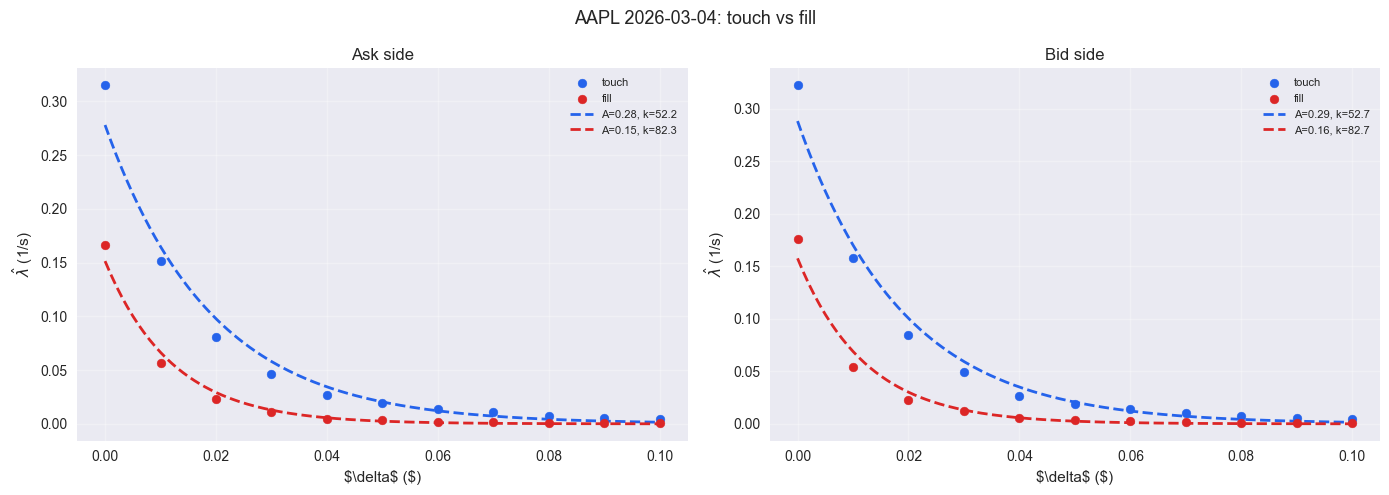


─────────────────────────────────────────────────────────────────
  AAPL | 2026-03-05 | L10
─────────────────────────────────────────────────────────────────


/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_29038/2455008719.py:18: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_29038/2455008719.py:18: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)


  Loaded: 2,959,015 events
  RTH: 2,927,301 snapshots, valid: 2,927,301
  Spread median: 0.0200
  σ̂ = 0.026517 $/√s
  Trades: 173,851  mean_price: 259.38
  Touch calibration...
  Touch:  Ask A=0.3232 k=53.89  |  Bid A=0.3281 k=52.32
  Fill calibration (queue-aware)...
    intervals=23,400  buy_agg=64,883  sell_agg=108,968
    fill calibration done in 0.4s
  Fill:   Ask A=0.1668 k=85.91  |  Bid A=0.1883 k=77.84


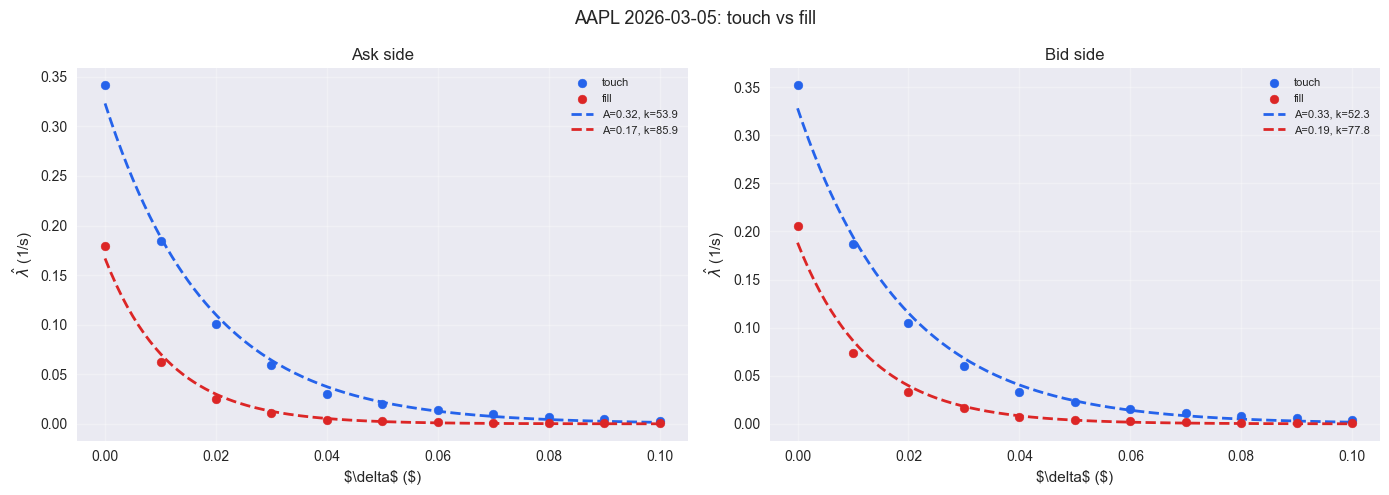


─────────────────────────────────────────────────────────────────
  AAPL | 2026-03-06 | L10
─────────────────────────────────────────────────────────────────


/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_29038/2455008719.py:18: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_29038/2455008719.py:18: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)


  Loaded: 2,507,718 events
  RTH: 2,478,894 snapshots, valid: 2,478,894
  Spread median: 0.0300
  σ̂ = 0.024841 $/√s
  Trades: 118,646  mean_price: 256.66
  Touch calibration...
  Touch:  Ask A=0.2677 k=57.92  |  Bid A=0.2834 k=56.83
  Fill calibration (queue-aware)...
    intervals=23,400  buy_agg=43,600  sell_agg=75,046
    fill calibration done in 0.4s
  Fill:   Ask A=0.1417 k=86.95  |  Bid A=0.1724 k=82.58


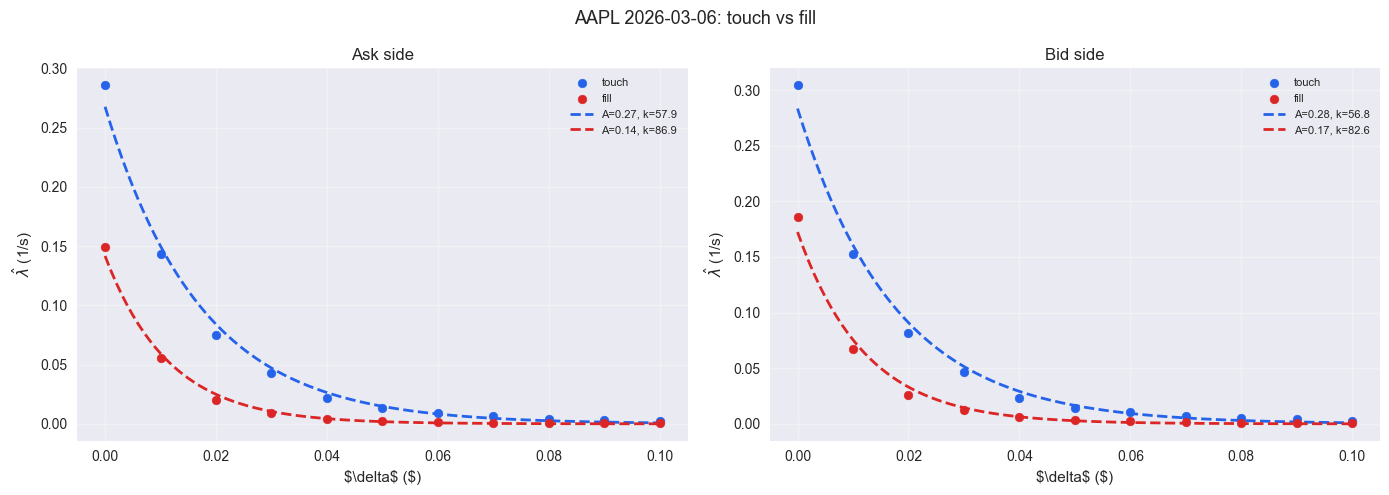


─────────────────────────────────────────────────────────────────
  SPY | 2026-03-04 | L10
─────────────────────────────────────────────────────────────────
  Loaded: 10,731,463 events
  RTH: 9,396,252 snapshots, valid: 9,396,252
  Spread median: 0.0100
  σ̂ = 0.033186 $/√s
  Trades: 207,543  mean_price: 684.88
  Touch calibration...
  Touch:  Ask A=0.4633 k=48.35  |  Bid A=0.4815 k=46.79
  Fill calibration (queue-aware)...
    intervals=23,400  buy_agg=94,052  sell_agg=113,491
    fill calibration done in 1.5s
  Fill:   Ask A=0.1624 k=105.47  |  Bid A=0.1852 k=100.98


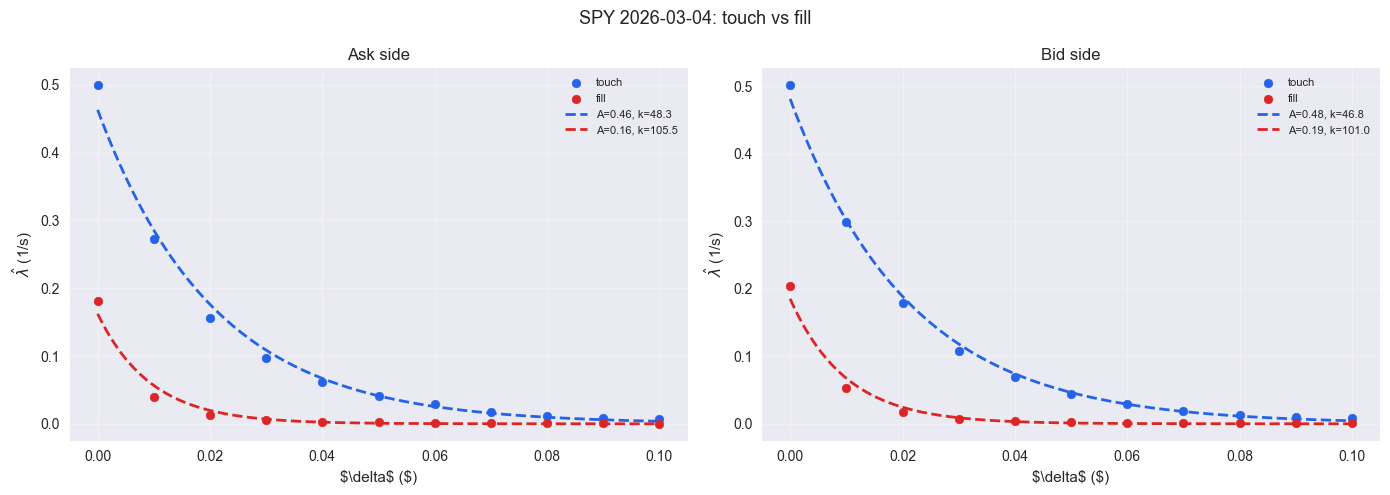


─────────────────────────────────────────────────────────────────
  SPY | 2026-03-05 | L10
─────────────────────────────────────────────────────────────────
  Loaded: 15,265,306 events
  RTH: 13,978,105 snapshots, valid: 13,978,105
  Spread median: 0.0200
  σ̂ = 0.044170 $/√s
  Trades: 331,328  mean_price: 679.85
  Touch calibration...
  Touch:  Ask A=0.5720 k=35.73  |  Bid A=0.6320 k=35.09
  Fill calibration (queue-aware)...
    intervals=23,400  buy_agg=142,292  sell_agg=189,036
    fill calibration done in 2.7s
  Fill:   Ask A=0.2329 k=99.50  |  Bid A=0.3040 k=89.33


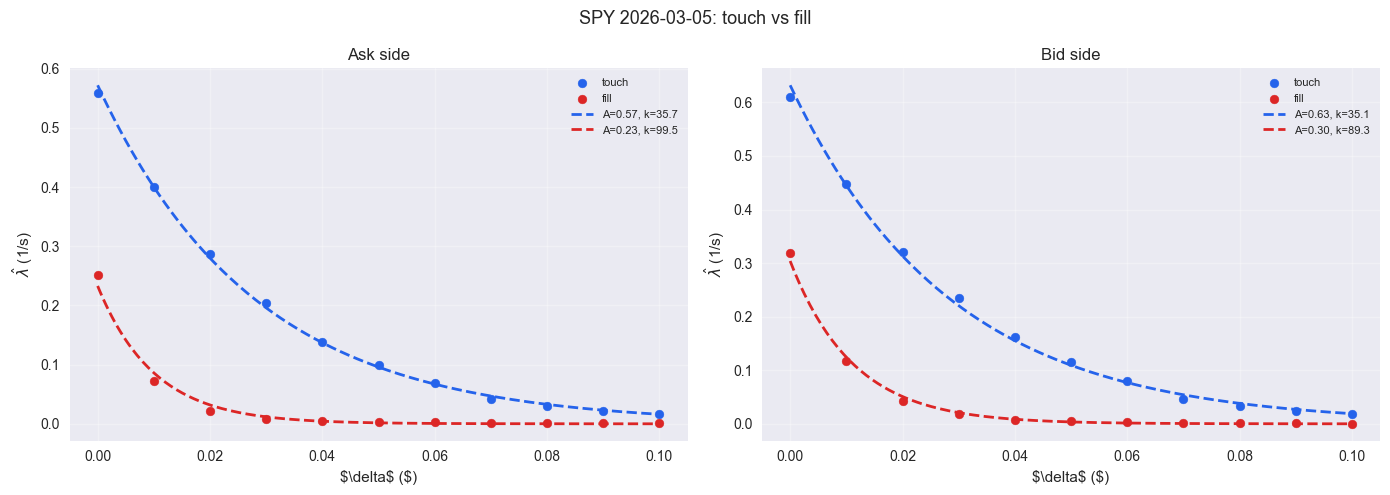


─────────────────────────────────────────────────────────────────
  SPY | 2026-03-06 | L10
─────────────────────────────────────────────────────────────────
  Loaded: 14,824,243 events
  RTH: 13,392,588 snapshots, valid: 13,392,588
  Spread median: 0.0200
  σ̂ = 0.047767 $/√s
  Trades: 305,012  mean_price: 673.56
  Touch calibration...
  Touch:  Ask A=0.5194 k=31.26  |  Bid A=0.5902 k=31.47
  Fill calibration (queue-aware)...
    intervals=23,400  buy_agg=132,709  sell_agg=172,303
    fill calibration done in 2.1s
  Fill:   Ask A=0.2045 k=88.00  |  Bid A=0.2505 k=79.98


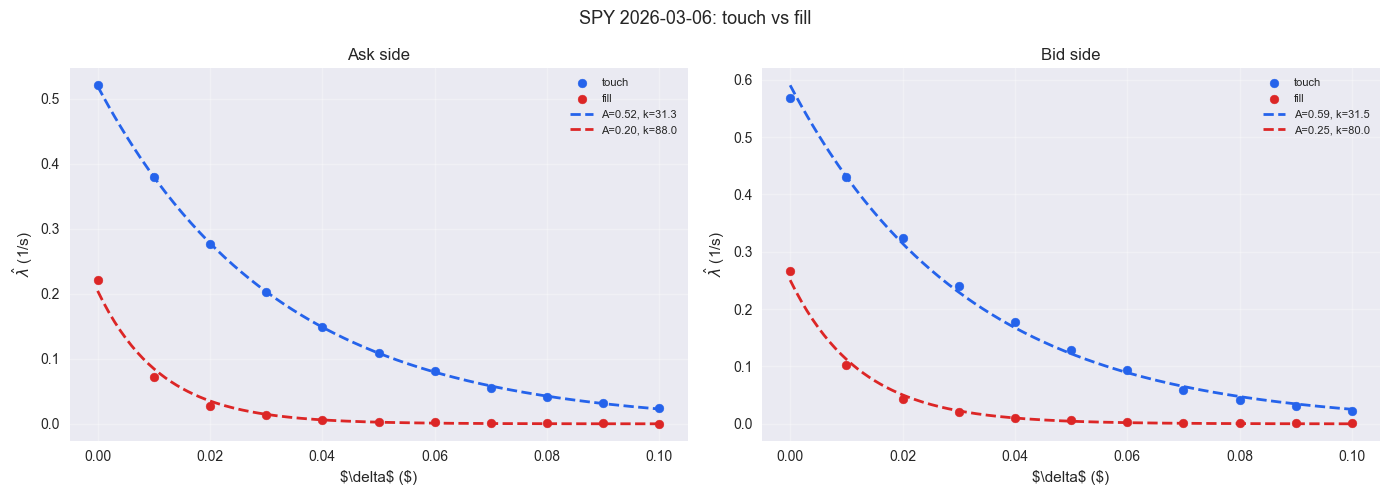


─────────────────────────────────────────────────────────────────
  TSLA | 2026-03-04 | L10
─────────────────────────────────────────────────────────────────


/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_29038/2455008719.py:18: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_29038/2455008719.py:18: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)


  Loaded: 2,940,294 events
  RTH: 2,782,657 snapshots, valid: 2,782,657
  Spread median: 0.0300
  σ̂ = 0.054608 $/√s
  Trades: 326,534  mean_price: 404.19
  Touch calibration...
  Touch:  Ask A=0.4045 k=31.21  |  Bid A=0.4134 k=29.47
  Fill calibration (queue-aware)...
    intervals=23,400  buy_agg=124,794  sell_agg=201,740
    fill calibration done in 0.4s
  Fill:   Ask A=0.2536 k=42.11  |  Bid A=0.2982 k=40.10


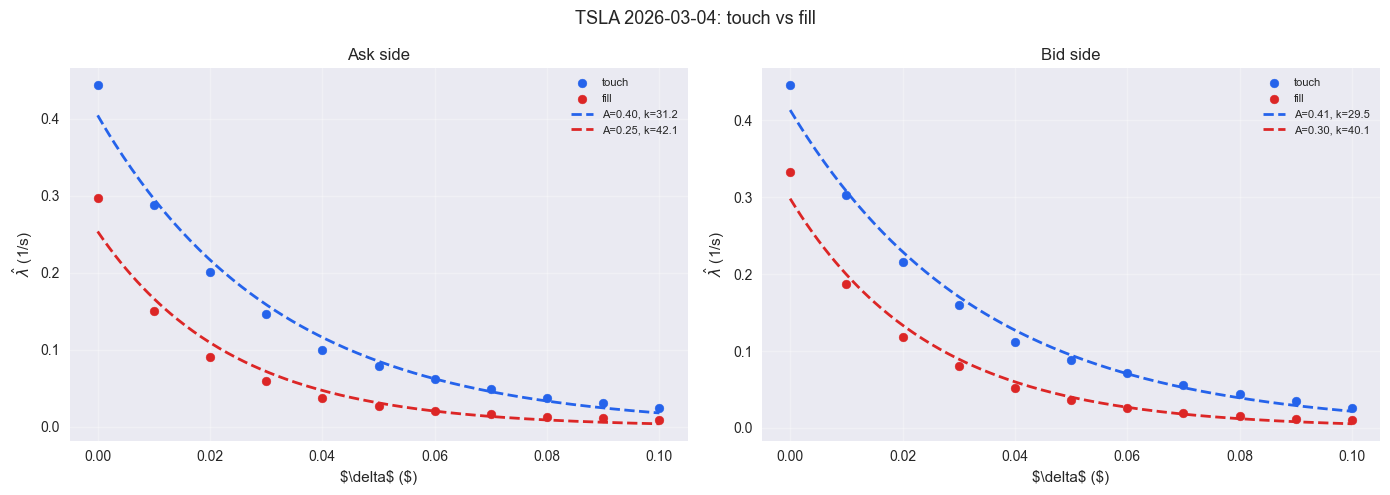


─────────────────────────────────────────────────────────────────
  TSLA | 2026-03-05 | L10
─────────────────────────────────────────────────────────────────


/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_29038/2455008719.py:18: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_29038/2455008719.py:18: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)


  Loaded: 2,561,256 events
  RTH: 2,444,958 snapshots, valid: 2,444,958
  Spread median: 0.0500
  σ̂ = 0.056574 $/√s
  Trades: 215,937  mean_price: 403.58
  Touch calibration...
  Touch:  Ask A=0.3292 k=29.35  |  Bid A=0.3534 k=27.27
  Fill calibration (queue-aware)...
    intervals=23,400  buy_agg=72,152  sell_agg=143,785
    fill calibration done in 0.4s
  Fill:   Ask A=0.1882 k=41.44  |  Bid A=0.2402 k=38.96


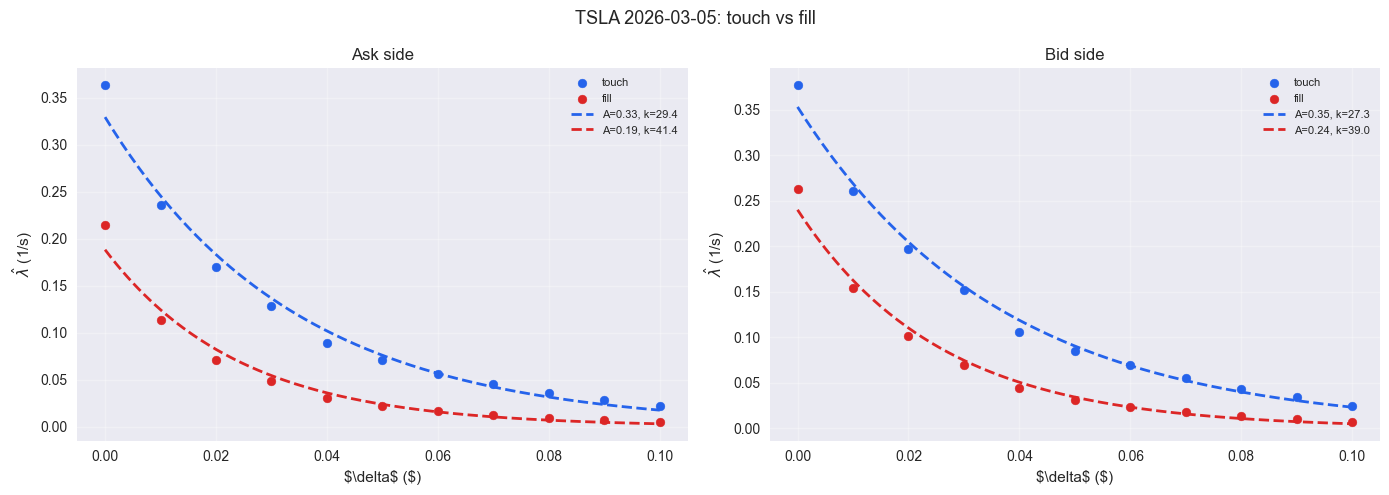


─────────────────────────────────────────────────────────────────
  TSLA | 2026-03-06 | L10
─────────────────────────────────────────────────────────────────


/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_29038/2455008719.py:18: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_29038/2455008719.py:18: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  msg_raw = pd.read_csv(msg_file, header=None, names=msg_cols, index_col=False)


  Loaded: 5,261,271 events
  RTH: 5,112,192 snapshots, valid: 5,112,192
  Spread median: 0.0400
  σ̂ = 0.053645 $/√s
  Trades: 317,164  mean_price: 398.19
  Touch calibration...
  Touch:  Ask A=0.4349 k=30.42  |  Bid A=0.4652 k=29.04
  Fill calibration (queue-aware)...
    intervals=23,400  buy_agg=112,770  sell_agg=204,394
    fill calibration done in 0.7s
  Fill:   Ask A=0.2849 k=56.91  |  Bid A=0.3387 k=50.29


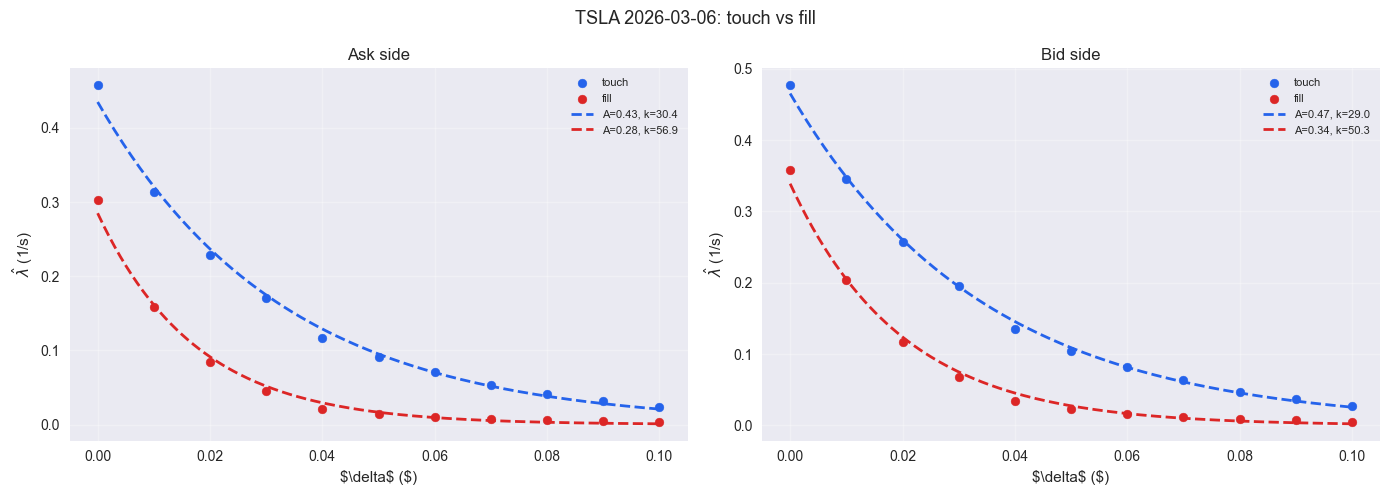


Completed: 9 folder(s)


,symbol,date,sigma_hat,A_fill_ask,k_fill_ask,A_fill_bid,k_fill_bid,n_trades
0,AAPL,2026-03-04,0.026305,0.151426,82.253464,0.157649,82.676556,137889
1,AAPL,2026-03-05,0.026517,0.166796,85.913463,0.188321,77.840538,173851
2,AAPL,2026-03-06,0.024841,0.141691,86.946577,0.172424,82.578772,118646
3,SPY,2026-03-04,0.033186,0.162374,105.474279,0.185169,100.976356,207543
4,SPY,2026-03-05,0.044170,0.232905,99.496214,0.303956,89.333844,331328
5,SPY,2026-03-06,0.047767,0.204513,87.999682,0.250511,79.982723,305012
6,TSLA,2026-03-04,0.054608,0.253610,42.111896,0.298160,40.095890,326534
7,TSLA,2026-03-05,0.056574,0.188174,41.435313,0.240231,38.958889,215937
8,TSLA,2026-03-06,0.053645,0.284923,56.905157,0.338747,50.285521,317164


In [8]:
tick_grid = np.arange(0, 11)

all_results = []
for folder in selected_folders:
    try:
        result = run_one_dataset(folder, tick_grid=tick_grid,
                                 make_plots=True, verbose=True)
        all_results.append(result)
    except Exception as e:
        print(f"  ✗ FAILED: {folder.name} — {e}")

results_df = pd.DataFrame(all_results)
print(f"\nCompleted: {len(results_df)} folder(s)")
results_df[["symbol", "date", "sigma_hat",
            "A_fill_ask", "k_fill_ask", "A_fill_bid", "k_fill_bid", "n_trades"]]

## Part 5 — Aggregate by symbol

In [9]:
summary_rows = []
for symbol, g in results_df.groupby("symbol"):
    row = {
        "symbol": symbol,
        "sigma": g["sigma_hat"].mean(),
        "A_touch_ask": g["A_touch_ask"].mean(),
        "k_touch_ask": g["k_touch_ask"].mean(),
        "A_touch_bid": g["A_touch_bid"].mean(),
        "k_touch_bid": g["k_touch_bid"].mean(),
        "A_fill_ask": g["A_fill_ask"].mean(),
        "k_fill_ask": g["k_fill_ask"].mean(),
        "A_fill_bid": g["A_fill_bid"].mean(),
        "k_fill_bid": g["k_fill_bid"].mean(),
        "n_days": g["date"].nunique(),
        "n_trades": int(g["n_trades"].sum()),
        "mean_price": g["mean_price"].mean(),
        "tick_size": g["tick_size"].iloc[0],
        "source": "LOBSTER L10, queue-aware fill approximation + touch proxy",
        "calibration_date": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
        "period": f"{g['date'].min()} -> {g['date'].max()}",
    }
    row["A"] = 0.5 * (row["A_fill_ask"] + row["A_fill_bid"])
    row["k"] = 0.5 * (row["k_fill_ask"] + row["k_fill_bid"])
    row["Delta"] = row["mean_price"]   # 1-share inventory unit
    row["Q"] = 4
    row["lot_size"] = 1
    row["r_squared"] = np.nan
    row["r_squared_ask"] = np.nan
    row["r_squared_bid"] = np.nan
    row["n_local_ticks"] = int(g["n_ticks_max"].max())
    summary_rows.append(row)

calibrated = {row["symbol"]: row for row in summary_rows}

for sym, p in calibrated.items():
    print(f"\n{sym} ({p['n_days']} day(s), {p['n_trades']:,} trades)")
    print(f"  σ = {p['sigma']:.6f} $/√s")
    print(f"  Fill (main):  A = {p['A']:.4f},  k = {p['k']:.2f}")
    print(f"  Fill ask:     A = {p['A_fill_ask']:.4f},  k = {p['k_fill_ask']:.2f}")
    print(f"  Fill bid:     A = {p['A_fill_bid']:.4f},  k = {p['k_fill_bid']:.2f}")
    print(f"  Touch ask:    A = {p['A_touch_ask']:.4f},  k = {p['k_touch_ask']:.2f}")
    print(f"  Touch bid:    A = {p['A_touch_bid']:.4f},  k = {p['k_touch_bid']:.2f}")
    if not np.isnan(p["A_touch_ask"]) and p["A_touch_ask"] > 0:
        print(f"  Ratio A_fill/A_touch ask = {p['A_fill_ask']/p['A_touch_ask']:.3f}")


AAPL (3 day(s), 430,386 trades)
  σ = 0.025887 $/√s
  Fill (main):  A = 0.1631,  k = 83.03
  Fill ask:     A = 0.1533,  k = 85.04
  Fill bid:     A = 0.1728,  k = 81.03
  Touch ask:    A = 0.2896,  k = 54.68
  Touch bid:    A = 0.3000,  k = 53.95
  Ratio A_fill/A_touch ask = 0.529

SPY (3 day(s), 843,883 trades)
  σ = 0.041708 $/√s
  Fill (main):  A = 0.2232,  k = 93.88
  Fill ask:     A = 0.1999,  k = 97.66
  Fill bid:     A = 0.2465,  k = 90.10
  Touch ask:    A = 0.5182,  k = 38.45
  Touch bid:    A = 0.5679,  k = 37.78
  Ratio A_fill/A_touch ask = 0.386

TSLA (3 day(s), 859,635 trades)
  σ = 0.054942 $/√s
  Fill (main):  A = 0.2673,  k = 44.97
  Fill ask:     A = 0.2422,  k = 46.82
  Fill bid:     A = 0.2924,  k = 43.11
  Touch ask:    A = 0.3895,  k = 30.33
  Touch bid:    A = 0.4106,  k = 28.59
  Ratio A_fill/A_touch ask = 0.622


## Part 6 — Cross-symbol comparison

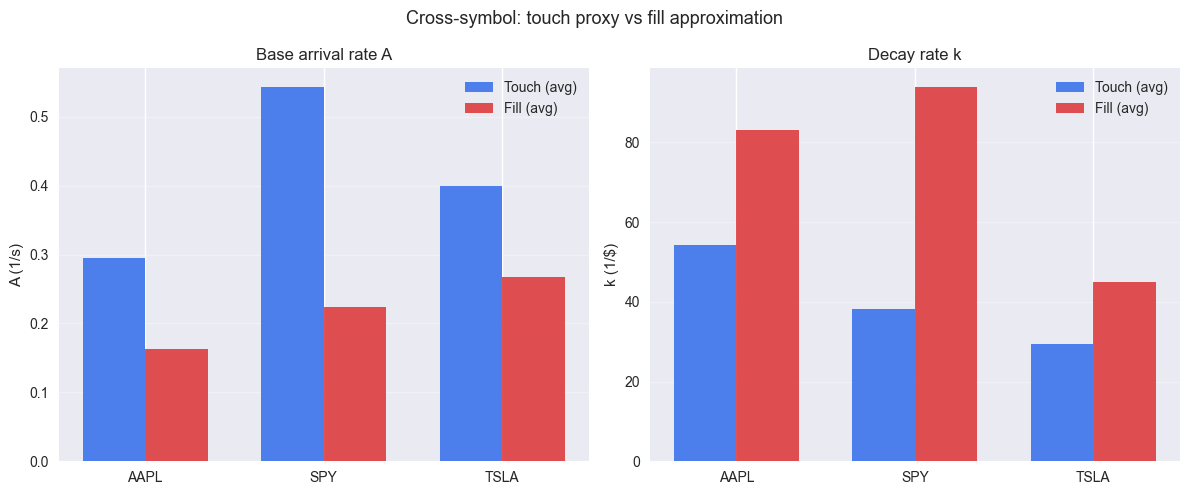

In [10]:
if len(calibrated) > 1:
    symbols_sorted = sorted(calibrated.keys())
    x = np.arange(len(symbols_sorted))
    w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    a_touch = [0.5*(calibrated[s]["A_touch_ask"]+calibrated[s]["A_touch_bid"])
               for s in symbols_sorted]
    a_fill = [calibrated[s]["A"] for s in symbols_sorted]
    axes[0].bar(x - w/2, a_touch, w, label="Touch (avg)", color="#2563EB", alpha=0.8)
    axes[0].bar(x + w/2, a_fill, w, label="Fill (avg)", color="#DC2626", alpha=0.8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(symbols_sorted)
    axes[0].set_ylabel("A (1/s)")
    axes[0].set_title("Base arrival rate A")
    axes[0].legend()
    axes[0].grid(alpha=0.3, axis="y")

    k_touch = [0.5*(calibrated[s]["k_touch_ask"]+calibrated[s]["k_touch_bid"])
               for s in symbols_sorted]
    k_fill = [calibrated[s]["k"] for s in symbols_sorted]
    axes[1].bar(x - w/2, k_touch, w, label="Touch (avg)", color="#2563EB", alpha=0.8)
    axes[1].bar(x + w/2, k_fill, w, label="Fill (avg)", color="#DC2626", alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(symbols_sorted)
    axes[1].set_ylabel("k (1/$)")
    axes[1].set_title("Decay rate k")
    axes[1].legend()
    axes[1].grid(alpha=0.3, axis="y")

    fig.suptitle("Cross-symbol: touch proxy vs fill approximation", fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print("Only one symbol — skipping cross-symbol comparison")

## Part 7 — Merge export into calibrated_params.json

Updates only the symbols recalculated in this run.
Does **not** overwrite other entries (BTCUSDT, ETHUSDT, etc.).

In [11]:
OUT_DIR = ROOT / "data" / "calibrated"
OUT_DIR.mkdir(parents=True, exist_ok=True)
json_path = OUT_DIR / "calibrated_params.json"

if json_path.exists():
    with open(json_path, "r") as f:
        params_export = json.load(f)
    print(f"Loaded existing JSON: {json_path}")
else:
    params_export = {}
    print("Creating new calibrated_params.json")

for symbol, p in calibrated.items():
    params_export[symbol] = {
        "sigma": round(float(p["sigma"]), 8),
        "A": round(float(p["A"]), 8),
        "k": round(float(p["k"]), 8),
        "Delta": round(float(p["Delta"]), 2),
        "Q": int(p["Q"]),
        "mean_price": round(float(p["mean_price"]), 4),
        "lot_size": int(p["lot_size"]),
        "A_ask": round(float(p["A_fill_ask"]), 8),
        "k_ask": round(float(p["k_fill_ask"]), 8),
        "A_bid": round(float(p["A_fill_bid"]), 8),
        "k_bid": round(float(p["k_fill_bid"]), 8),
        "n_trades": int(p["n_trades"]),
        "n_days": int(p["n_days"]),
        "total_hours": round(float(6.5 * p["n_days"]), 2),
        "period": p["period"],
        "tick_size": float(p["tick_size"]),
        "n_local_ticks": int(p["n_local_ticks"]),
        "source": p["source"],
        "calibration_date": p["calibration_date"],
        "methodology_note": (
            "Queue-aware passive fill approximation on LOBSTER level-10 order book data. "
            "Quotes defined in ticks from the same-side best price. "
            "Touch intensity and fill approximation calibrated separately on ask and bid sides. "
            "Displayed queue ahead approximated from visible depth only. "
            "Worst-case assumption: hypothetical order enters at the back of the queue. "
            "Cancellations ahead within interval are not explicitly reconstructed."
        ),
    }
    print(f"  Updated: {symbol}")

with open(json_path, "w") as f:
    json.dump(params_export, f, indent=2)

print(f"\n✓ Saved merged JSON: {json_path}")
print(f"  Symbols in file: {list(params_export.keys())}")

Creating new calibrated_params.json
  Updated: AAPL
  Updated: SPY
  Updated: TSLA

✓ Saved merged JSON: /Users/hamzaelarji/Desktop/All/Bureau/cours/Imperial College/Term 2/Elective modules/Chosen Elective Modules /Market Microstructure/Coursework/Market-Microstructure-/project/data/data/data/calibrated/calibrated_params.json
  Symbols in file: ['AAPL', 'SPY', 'TSLA']




### Overview of the two calibration frameworks

We performed two distinct empirical calibrations of the exponential intensity model  
$\Lambda(\delta) = A e^{-k \delta}$ using two fundamentally different data sources. The first calibration is based on crypto assets (BTCUSDT and ETHUSDT) using Tardis level-1 data, which consists only of best bid/ask quotes and trade prints. The second calibration is based on US equities (AAPL, SPY, TSLA) using LOBSTER level-10 order book data, which provides access to multiple levels of depth.

The key methodological difference lies in the level of observability of the order book. In the crypto setting, only top-of-book information is available, and the calibration relies on a hypothetical-quote maximum likelihood procedure without any information on queue position or depth. As a result, the estimated intensity should be interpreted as a reduced-form proxy for passive execution. In contrast, the LOBSTER dataset allows us to approximate the queue ahead of a hypothetical order using visible depth, leading to a queue-aware fill approximation that is much closer to the true execution process.

### Stability and statistical quality of the calibration

A major difference between the two datasets appears in the statistical quality of the fit. In the crypto case, the exponential model exhibits weak explanatory power. For BTCUSDT, we obtain $A \approx 0.50$ and $k \approx 1.01$ with a very low $R^2 \approx 0.06$, indicating that the model fails to capture the empirical intensity curve. For ETHUSDT, the fit is slightly better, with $A \approx 0.76$, $k \approx 8.60$, and $R^2 \approx 0.37$, but remains relatively poor.

These low $R^2$ values suggest that the exponential specification is not well supported by L1 crypto data. The observed intensities are highly noisy, and the relationship between quote distance and execution probability is not well captured by a simple exponential decay.

In contrast, the LOBSTER calibration produces much more stable and consistent parameters across assets and days. For example, we obtain $k$ values typically between 40 and 100, and $A$ values in a narrow range across AAPL, SPY, and TSLA. Even without explicitly computing $R^2$, the smoothness of the fitted curves and the consistency across assets strongly indicate a much better fit of the exponential model to high-quality order book data.

### Structural differences in the estimated parameters

The estimated parameters exhibit significant structural differences between crypto and equities. In the crypto case, the decay parameter $k$ is relatively small, especially for BTCUSDT, indicating a slow decay of intensity with distance. This reflects a market where large price movements are more frequent and liquidity is less concentrated around the best quotes.

In contrast, equities display much larger values of $k$, implying a very sharp decay of execution probability as the quote moves away from the best price. This is consistent with a tighter and deeper order book, where most of the liquidity is concentrated near the top of the book and execution probabilities decrease rapidly with distance.

These differences highlight fundamental distinctions in market microstructure between crypto and traditional equities markets.

### Role of queue effects in LOBSTER data

A key advantage of the LOBSTER dataset is the ability to distinguish between touch intensity and fill intensity. The touch intensity measures whether the price reaches a given level, while the fill intensity accounts for whether a passive order would actually be executed, given the queue ahead.

By construction, the fill intensity is always lower than the touch intensity. This reflects the fact that reaching a price level is not sufficient for execution, as the order must also overcome the volume already resting in the book. This queue effect captures an essential aspect of market microstructure that is completely absent in the crypto calibration, where no depth information is available.

### Implications for the Guéant model

The Guéant (2017) framework assumes a smooth exponential relationship between quote distance and execution intensity, as well as a well-defined notion of passive execution. Our empirical results show that these assumptions are strongly dependent on the quality of the data used for calibration.

In the crypto setting, the exponential model provides a poor fit, and the absence of queue information introduces a significant modeling bias. The calibrated parameters should therefore be interpreted as reduced-form quantities rather than structural parameters of the execution process.

In contrast, the LOBSTER calibration yields stable and economically meaningful parameters. The incorporation of queue-aware fill approximations significantly improves the realism of the model, making it much more consistent with the theoretical assumptions of Guéant.

### Key takeaway

The main conclusion of this analysis is that the validity of the exponential intensity model depends critically on the level of order book observability. When only L1 data is available, the model is weakly supported and produces noisy and unstable estimates. When richer order book data is available, even a partial reconstruction of the queue leads to a substantial improvement in both statistical fit and economic interpretability.

### Final insight

This comparison highlights that market making models such as Guéant (2017) are not purely theoretical constructions, but are deeply dependent on the granularity and quality of the data used for calibration. In particular, the absence of queue information in L1 data leads to a substantial misspecification of passive execution dynamics, while even a partial reconstruction of the order book significantly improves both the statistical and economic validity of the model.